#### Dataset
- Name: Titanic Dataset
- Task: Binary Classification
- Source: Kaggle
- Reference: Link: https://www.kaggle.com/c/titanic


<h1> K-Nearest Neighbors (KNN) 

**In this notebook, we first implement knn manually—from scratch—and then compare it with a ready-made model from a library.**

The first instance-based learning algorithm

KNN differs significantly from Logistic Regression. While Logistic Regression is a parametric model that learns weights, KNN learns virtually no explicit model; instead, it stores the training data and searches for the nearest samples during prediction. For this reason, it is referred to as "instance-based" or "lazy learning."

For a new sample $x$, the KNN process is as follows:

$$ x \rightarrow \text{calculate distances} \rightarrow \text{find } k \text{ nearest neighbors} \rightarrow \text{majority vote} \rightarrow \hat y $$

Here is a crucial point: scaling is extremely important in KNN because the algorithm relies directly on distance. If one feature ranges from 0 to 1 while another ranges from 0 to 10,000, the second feature will effectively dominate the distance calculation. Therefore, the `StandardScaler` used in the Titanic pipeline is highly beneficial for KNN as well.

This is the most important difference between `fit()` in this context and in Logistic Regression. In Logistic Regression:

`fit()`

actually learns something using Gradient Descent. However, in KNN:

`self.X_train = X`</br>
`self.y_train = y`

essentially, only the training data is stored; the bulk of the computation takes place during `predict()`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from src.knn import KNearestNeighbors
from sklearn.neighbors import KNeighborsClassifier

c:\Users\niush\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


<h3> Step 1: Dataset

<h3> Step 1.1: Load The Dataset

In [2]:
df = pd.read_csv(
    "../../../datasets/Titanic-Dataset/processed/titanic_feature_engineered.csv"
)

df.head()

,Survived,Age,Fare,FamilySize,FarePerPerson,SibSp,Parch,Sex,Embarked,FamilyCategory,Title,Deck
0,0,22.0,7.2500,2,3.62500,1,0,male,S,Small,Mr,Unknown
1,1,38.0,71.2833,2,35.64165,1,0,female,C,Small,Mrs,C
2,1,26.0,7.9250,1,7.92500,0,0,female,S,Alone,Miss,Unknown
3,1,35.0,53.1000,2,26.55000,1,0,female,S,Small,Mrs,C
4,0,35.0,8.0500,1,8.05000,0,0,male,S,Alone,Mr,Unknown


<h3> Step 1.2: Dataset Analysis

In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        891 non-null    int64  
 1   Age             714 non-null    float64
 2   Fare            891 non-null    float64
 3   FamilySize      891 non-null    int64  
 4   FarePerPerson   891 non-null    float64
 5   SibSp           891 non-null    int64  
 6   Parch           891 non-null    int64  
 7   Sex             891 non-null    object 
 8   Embarked        889 non-null    object 
 9   FamilyCategory  891 non-null    object 
 10  Title           891 non-null    object 
 11  Deck            891 non-null    object 
dtypes: float64(3), int64(4), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,Survived,Age,Fare,FamilySize,FarePerPerson,SibSp,Parch
count,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,32.204208,1.904602,19.916375,0.523008,0.381594
std,0.486592,14.526497,49.693429,1.613459,35.841257,1.102743,0.806057
min,0.000000,0.420000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,7.910400,1.000000,7.250000,0.000000,0.000000
50%,0.000000,28.000000,14.454200,1.000000,8.300000,0.000000,0.000000
75%,1.000000,38.000000,31.000000,2.000000,23.666667,1.000000,0.000000
max,1.000000,80.000000,512.329200,11.000000,512.329200,8.000000,6.000000


In [6]:
df.isnull().sum()

Survived            0
Age               177
Fare                0
FamilySize          0
FarePerPerson       0
SibSp               0
Parch               0
Sex                 0
Embarked            2
FamilyCategory      0
Title               0
Deck                0
dtype: int64

<h3> Step 1.3: Separate X and y

In [7]:
X = df.drop(
    "Survived",
    axis=1
)

y = df["Survived"]

In [8]:
print(X.shape)
print(y.shape)

(891, 11)
(891,)


<h3> Step 1.4: Identify Numerical and Categorical Features

In [9]:
numeric_features = X.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=[
        "object"
    ]
).columns.tolist()


print(
    "Numerical Features:"
)

print(
    numeric_features
)

print(
    "\nCategorical Features:"
)

print(
    categorical_features
)

Numerical Features:
['Age', 'Fare', 'FamilySize', 'FarePerPerson', 'SibSp', 'Parch']

Categorical Features:
['Sex', 'Embarked', 'FamilyCategory', 'Title', 'Deck']


<h3> Step 1.5: Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    X_train.shape
)
print(
    X_test.shape
)

(712, 11)
(179, 11)


<h3> Step 1.6: Pipelines

In [11]:
numeric_transformer = Pipeline(
    steps=[
        
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [12]:
categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

<h3> Step 1.7: fit on Train + transform

In [14]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [15]:
print(
    X_train_processed.shape
)

print(
    X_test_processed.shape
)

(712, 28)
(179, 28)


<h3> Step 2: Building The Model

Unlike logistic regression, here we don't have things like:

weights</br>
bias</br>
loss

because KNN is not a parametric model.

In essence:

Training:</br>
Storing data.

Prediction:</br>
Calculating distance + voting.

<h3> Step 2.1: The Model

In [16]:
knn_model = KNearestNeighbors(
    k=5
)

<h3> Step 2.2: Fit

In [17]:
knn_model.fit(
    X_train_processed,
    y_train.values
)

<h3> Step 2.3: Predict

In [18]:
y_pred_knn = knn_model.predict(
    X_test_processed
)

<h3> Step 2.4: Initial Test

In [19]:
print(
    y_pred_knn[:10]
)

print(
    y_test.values[:10]
)

[0 0 0 0 1 1 0 0 0 0]
[0 0 1 0 1 1 1 0 0 0]


<h3> Step 3: Evaluation KNN

<h3> Step 3.1: Accuracy

In [20]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print(
    "Accuracy:",
    knn_accuracy
)

Accuracy: 0.7932960893854749


<h3> Step 3.2: Precision

In [21]:
knn_precision = precision_score(
    y_test,
    y_pred_knn
)

print(
    "Precision:",
    knn_precision
)

Precision: 0.7962962962962963


<h3> Step 3.3: Recall

In [22]:
knn_recall = recall_score(
    y_test,
    y_pred_knn
)

print(
    "Recall:",
    knn_recall
)

Recall: 0.6231884057971014


<h3> Step 3.4: F1 Score

In [23]:
knn_f1 = f1_score(
    y_test,
    y_pred_knn
)

print(
    "F1-score:",
    knn_f1
)

F1-score: 0.6991869918699186


<h3> Step 3.5: Classification report

In [24]:
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       110
           1       0.80      0.62      0.70        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179



<h3> Step 3.6: Confusion Matrix

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred_knn
)

print("Confusion Matrix: \n", cm)

Confusion Matrix: 
 [[99 11]
 [26 43]]


<h3> Step 4: Comparison with Logistic Regression

| Model               | Accuracy | Precision(1) | Recall(1) |    F1 |
| ------------------- | -------: | -----------: | --------: | ----: |
| Logistic Regression |    0.827 |        0.806 |     0.725 | 0.763 |
| KNN (k=5)           |    0.793 |        0.796 |     0.623 | 0.699 |


In this dataset:

Logistic Regression performed better.

Possible reasons:
1) The relationship between features is relatively linear.
2) KNN is sensitive to the quality of the distance metric.
3) The curse of dimensionality.

<h3> Step 5: Effect of K Value (Bias-Variance Tradeoff)

In [26]:
k_values = [
    1,
    3,
    5,
    7,
    9,
    15,
    20,
    25,
    30,
    40,
    50,
    75,
    100
]

train_scores = []
test_scores = []

f1_scores = []

In [27]:
for k in k_values:

    print(
        f"K = {k}"
    )

    knn_model = KNearestNeighbors(
        k=k
    )

    knn_model.fit(
        X_train_processed,
        y_train.values
    )

    # Train prediction
    y_train_pred = knn_model.predict(
        X_train_processed
    )

    # Test prediction
    y_test_pred = knn_model.predict(
        X_test_processed
    )

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred
    )

    train_scores.append(
        train_accuracy
    )

    test_scores.append(
        test_accuracy
    )

    f1_scores.append(
        test_f1
    )

    print(
        "Train Accuracy:",
        train_accuracy
    )

    print(
        "Test Accuracy:",
        test_accuracy
    )

    print(
        "F1:",
        test_f1
    )

    print("----------------")

K = 1
Train Accuracy: 0.9817415730337079
Test Accuracy: 0.7318435754189944
F1: 0.6307692307692307
----------------
K = 3
Train Accuracy: 0.8764044943820225
Test Accuracy: 0.776536312849162
F1: 0.6923076923076924
----------------
K = 5
Train Accuracy: 0.8553370786516854
Test Accuracy: 0.7932960893854749
F1: 0.6991869918699186
----------------
K = 7
Train Accuracy: 0.8384831460674157
Test Accuracy: 0.770949720670391
F1: 0.672
----------------
K = 9
Train Accuracy: 0.8370786516853933
Test Accuracy: 0.7877094972067039
F1: 0.703125
----------------
K = 15
Train Accuracy: 0.8258426966292135
Test Accuracy: 0.8044692737430168
F1: 0.7286821705426356
----------------
K = 20
Train Accuracy: 0.8160112359550562
Test Accuracy: 0.7932960893854749
F1: 0.7086614173228347
----------------
K = 25
Train Accuracy: 0.8146067415730337
Test Accuracy: 0.8212290502793296
F1: 0.7575757575757576
----------------
K = 30
Train Accuracy: 0.8202247191011236
Test Accuracy: 0.8156424581005587
F1: 0.7480916030534351
---

In [28]:
knn_results = pd.DataFrame(
    {
        "K": k_values,
        "Train Accuracy": train_scores,
        "Test Accuracy": test_scores,
        "Test F1": f1_scores
    }
)

knn_results

,K,Train Accuracy,Test Accuracy,Test F1
0,1,0.981742,0.731844,0.630769
1,3,0.876404,0.776536,0.692308
2,5,0.855337,0.793296,0.699187
3,7,0.838483,0.770950,0.672000
4,9,0.837079,0.787709,0.703125
5,15,0.825843,0.804469,0.728682
6,20,0.816011,0.793296,0.708661
7,25,0.814607,0.821229,0.757576
8,30,0.820225,0.815642,0.748092
9,40,0.814607,0.810056,0.738462


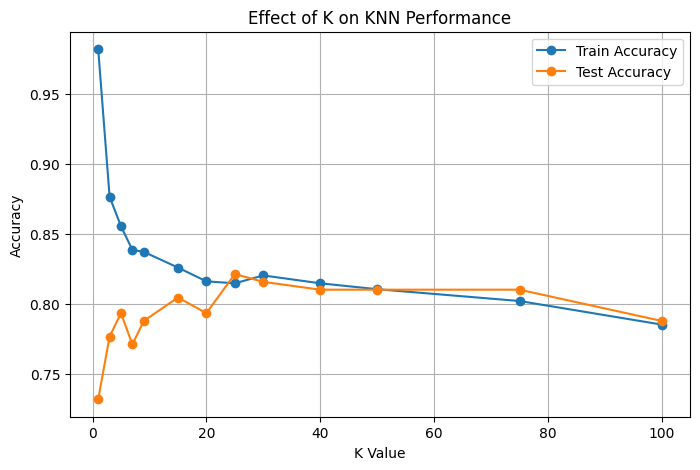

In [29]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    k_values,
    train_scores,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    k_values,
    test_scores,
    marker="o",
    label="Test Accuracy"
)

plt.xlabel(
    "K Value"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Effect of K on KNN Performance"
)

plt.legend()
plt.grid()
plt.show()

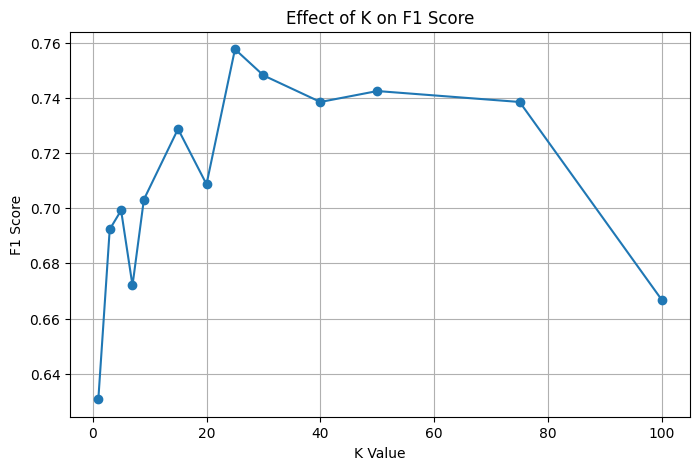

In [30]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    k_values,
    f1_scores,
    marker="o"
)

plt.xlabel(
    "K Value"
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Effect of K on F1 Score"
)

plt.grid()
plt.show()

### Effect of K Value

The value of k controls the bias-variance tradeoff in KNN.

A small k value (k=1) resulted in very high training accuracy but lower test performance, indicating overfitting.

Increasing k reduced variance and improved generalization.

The best performance was achieved with k=25:

- Test Accuracy: 82.1%
- Test F1-score: 75.8%

However, very large k values increased bias and slightly reduced performance.

<h3> Step 6: Compare Custom KNN vs Scikit-Learn KNN

The best value of \($k$\) we found:

k = 25

So, we perform the comparison using this value.

our manual model

In [37]:
best_knn = KNearestNeighbors(
    k=25
)

best_knn.fit(
    X_train_processed,
    y_train.values
)

y_pred_custom_best = best_knn.predict(
    X_test_processed
)

In [38]:
# Evaluation

# Accuracy
custom_knn_accuracy = accuracy_score(
    y_test,
    y_pred_custom_best
)

# Precision
custom_knn_precision = precision_score(
    y_test,
    y_pred_custom_best
)

# Recall
custom_knn_recall = recall_score(
    y_test,
    y_pred_custom_best
)

# F1
custom_knn_f1 = f1_score(
    y_test,
    y_pred_custom_best
)

# Confusion Matrix
custom_knn_cm = confusion_matrix(
    y_test,
    y_pred_custom_best
)

pre-made model

In [39]:
# Building an scikit-learn model
sklearn_knn = KNeighborsClassifier(
    n_neighbors=25
)

# Training
sklearn_knn.fit(
    X_train_processed,
    y_train
)

# Prediction
y_pred_sklearn_knn = sklearn_knn.predict(
    X_test_processed
)

In [40]:
# Evaluation

# Accuracy
sklearn_knn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn_knn
)

# Precision
sklearn_knn_precision = precision_score(
    y_test,
    y_pred_sklearn_knn
)

# Recall
sklearn_knn_recall = recall_score(
    y_test,
    y_pred_sklearn_knn
)

# F1
sklearn_knn_f1 = f1_score(
    y_test,
    y_pred_sklearn_knn
)

# Confusion Matrix
sklearn_knn_cm = confusion_matrix(
    y_test,
    y_pred_sklearn_knn
)

In [41]:
knn_comparison = pd.DataFrame(
    {
        "Model": [
            "Custom KNN",
            "Scikit-Learn KNN"
        ],

        "Accuracy": [
            custom_knn_accuracy,
            sklearn_knn_accuracy
        ],

        "Precision": [
            custom_knn_precision,
            sklearn_knn_precision
        ],

        "Recall": [
            custom_knn_recall,
            sklearn_knn_recall
        ],

        "F1-score": [
            custom_knn_f1,
            sklearn_knn_f1
        ],
        
        "Confusion-Matrix": [
            custom_knn_cm,
            sklearn_knn_cm
        ]
    }
)

knn_comparison

,Model,Accuracy,Precision,Recall,F1-score,Confusion-Matrix
0,Custom KNN,0.821229,0.793651,0.724638,0.757576,"[[97, 13], [19, 50]]"
1,Scikit-Learn KNN,0.821229,0.793651,0.724638,0.757576,"[[97, 13], [19, 50]]"


### Final KNN Results

The custom KNN implementation was evaluated using the optimal value of k obtained from hyperparameter analysis.

The best performance was achieved with:

- k = 25

The model achieved:

- Accuracy: 82.1%
- F1-score: 75.8%

The custom implementation was compared with Scikit-Learn's KNeighborsClassifier using the same parameters.

Both implementations produced identical predictions and evaluation metrics, confirming the correctness of the manually implemented KNN algorithm.

The results demonstrate that KNN can successfully learn patterns from the engineered Titanic features, although its performance is slightly affected by the high-dimensional feature space after one-hot encoding.